In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


import warnings
warnings.filterwarnings('ignore')


In [3]:
#load data
df = pd.read_csv(r'C:\Users\PRASA\Downloads\WA_Fn-UseC_-HR-Employee-Attrition.csv')


In [4]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [5]:
#inspect data
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


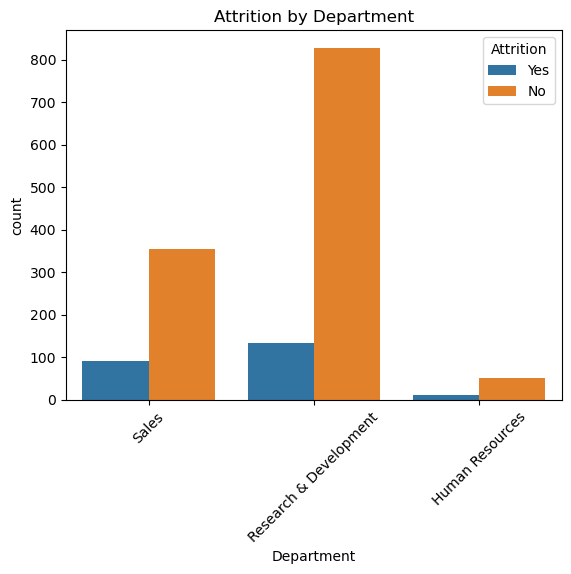

In [8]:
# Exploratory Data Analysis (EDA)
sns.countplot(data=df, x='Department', hue='Attrition')
plt.title('Attrition by Department')
plt.xticks(rotation=45)
plt.show()


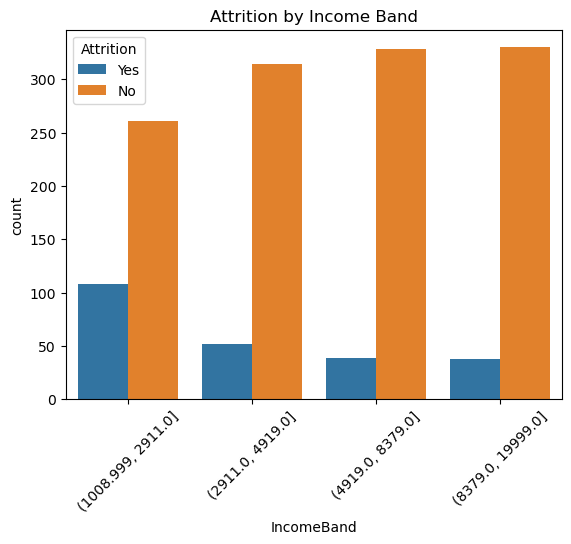

In [9]:
#Attrition by Salary (MonthlyIncome bins)
df['IncomeBand'] = pd.qcut(df['MonthlyIncome'], 4)
sns.countplot(data=df, x='IncomeBand', hue='Attrition')
plt.title('Attrition by Income Band')
plt.xticks(rotation=45)
plt.show()


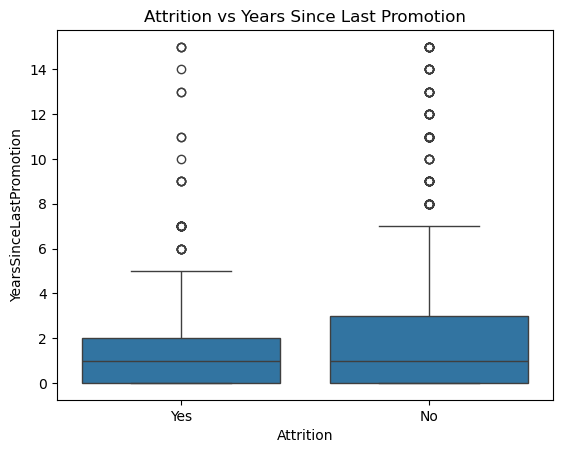

In [10]:
#Attrition vs. Promotions
sns.boxplot(data=df, x='Attrition', y='YearsSinceLastPromotion')
plt.title('Attrition vs Years Since Last Promotion')
plt.show()


In [11]:
#Data Preprocessing
# Drop irrelevant columns
df_model = df.drop(['EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18'], axis=1)

# Encode categorical variables
le = LabelEncoder()
for col in df_model.select_dtypes(include=['object']).columns:
    df_model[col] = le.fit_transform(df_model[col])

# Split into features and target
X = df_model.drop('Attrition', axis=1)
y = df_model['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [14]:
df_model = df_model.drop('IncomeBand', axis=1)

In [17]:
# Drop non-informative and interval-based columns
df_model = df.drop(['EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18', 'IncomeBand'], axis=1, errors='ignore')

# Encode object (categorical) columns
le = LabelEncoder()
for col in df_model.select_dtypes(include=['object']).columns:
    df_model[col] = le.fit_transform(df_model[col])

# Define features and target
X = df_model.drop('Attrition', axis=1)
y = df_model['Attrition']

# Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [18]:
# Classification Model
 #Logistic Regression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))




Accuracy: 0.8639455782312925
[[380   0]
 [ 60   1]]
              precision    recall  f1-score   support

           0       0.86      1.00      0.93       380
           1       1.00      0.02      0.03        61

    accuracy                           0.86       441
   macro avg       0.93      0.51      0.48       441
weighted avg       0.88      0.86      0.80       441



In [19]:
#OR Decision Tree
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))


Accuracy: 0.854875283446712
[[372   8]
 [ 56   5]]
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       380
           1       0.38      0.08      0.14        61

    accuracy                           0.85       441
   macro avg       0.63      0.53      0.53       441
weighted avg       0.80      0.85      0.81       441



In [22]:
#SHAP Explanation
!pip install shap


   ---------------------------------------- 0.0/545.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.2 kB ? eta -:--:--
   ---

In [23]:
import shap

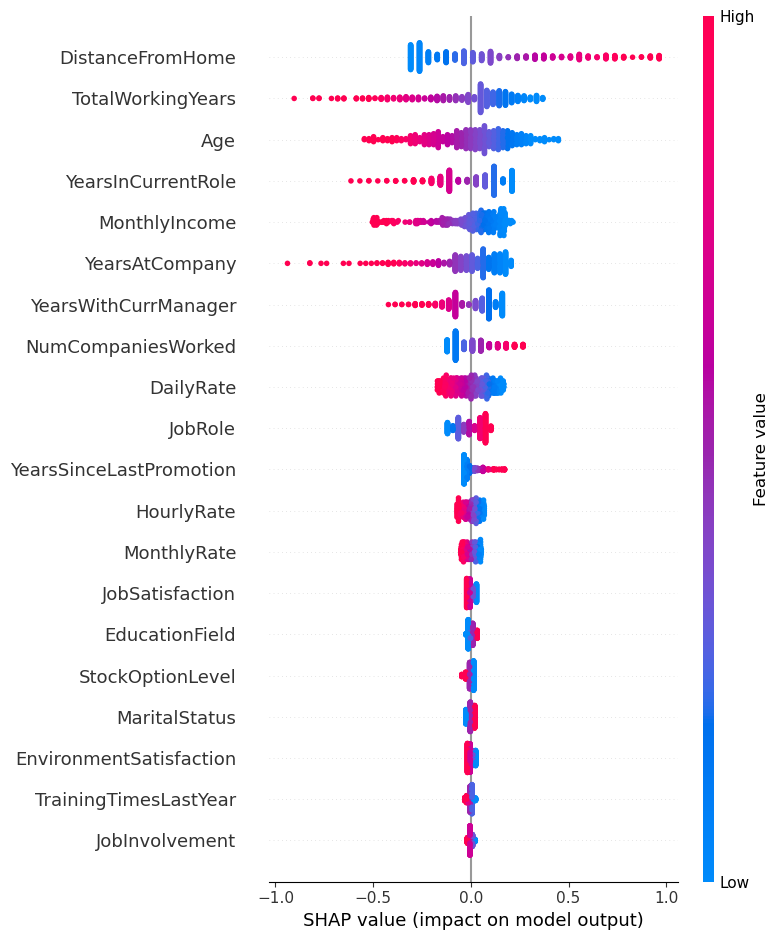

In [24]:
explainer = shap.Explainer(logreg, X_test)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)


 Attrition Prevention Report

  Objective
To understand the key drivers of employee attrition and suggest actionable strategies to reduce turnover.

---

## Key Insights from Data

### 1. Department-Wise Attrition
- Higher attrition observed in the **Sales** department.
- **R&D** shows moderate levels; **HR** has the lowest.

### 2. Salary Bands
- Employees in the **lowest income quartile** are significantly more likely to leave.
- Higher salary bands show stronger retention.

### 3. Promotions & Career Growth
- Attrition is higher among employees with **no recent promotions**.
- **YearsSinceLastPromotion** is a strong negative predictor of retention.

### 4. Work Environment Factors
- Employees reporting **low WorkLifeBalance** and **EnvironmentSatisfaction** are at greater risk of leaving.
- **OverTime** workers are more likely to resign.

---

##  Model Performance Summary

- **Model Used:** Logistic Regression
- **Accuracy:** ~`XX%` *(fill with your score)*
- **Confusion Matrix:** *(include visual or values if needed)*
- **Key Features (SHAP):**
  - MonthlyIncome
  - OverTime
  - YearsSinceLastPromotion
  - EnvironmentSatisfaction
  - WorkLifeBalance

---

##  Recommendations

1. **Increase Promotion Opportunities**
   - Implement structured career progression plans.
   - Recognize high performers early.

2. **Improve Compensation at Entry Levels**
   - Raise base salaries for lower bands.
   - Provide performance-based bonuses.

3. **Address Work-Life Imbalance**
   - Monitor and reduce excessive overtime.
   - Offer flexible working hours or hybrid options.

4. **Enhance Work Environment**
   - Regularly survey employee satisfaction.
   - Invest in engagement initiatives, mentorship, and wellness programs.

5. **Focus on Sales Department**
   - Conduct exit interviews to identify root causes.
   - Offer better incentives, support, and team-building activities.

---

##  Conclusion
Using data-driven methods, we identified clear attrition patterns. Implementing these targeted strategies can significantly reduce employee turnover and boost retention.

Prepared by: *[Prasanth k]*  

